In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
import zipfile

zip_path = '/content/drive/MyDrive/Lms project/archive (2).zip'  # Adjust if the path is different
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipping complete!")


Unzipping complete!


In [5]:
import os

for root, dirs, files in os.walk('/content/dataset'):
    print("Folder:", root)
    print("Files:", files[:5])  # Show first 5 files
    break


Folder: /content/dataset
Files: []


In [6]:
import os

for root, dirs, files in os.walk('/content/dataset'):
    print("Current folder:", root)
    print("Subfolders:", dirs)
    print("Files:", files[:5])  # Show first 5 files if any
    print("-" * 40)


Current folder: /content/dataset
Subfolders: ['New Plant Diseases Dataset(Augmented)', 'new plant diseases dataset(augmented)', 'test']
Files: []
----------------------------------------
Current folder: /content/dataset/New Plant Diseases Dataset(Augmented)
Subfolders: ['New Plant Diseases Dataset(Augmented)']
Files: []
----------------------------------------
Current folder: /content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)
Subfolders: ['valid', 'train']
Files: []
----------------------------------------
Current folder: /content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
Subfolders: ['Tomato___Bacterial_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Squash___Powdery_mildew', 'Tomato___Early_blight', 'Peach___healthy', 'Raspberry___healthy', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Grap

In [7]:
!pip install tensorflow --quiet


In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os


In [9]:
train_dir = "/content/dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train"
test_dir = "/content/dataset/test/test"


In [10]:
img_height, img_width = 224, 224
batch_size = 32

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training')

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation')


Found 56251 images belonging to 38 classes.
Found 14044 images belonging to 38 classes.


In [11]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),  # Use this instead of input_shape in Conv2D
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(train_generator.num_classes, activation='softmax')
])


In [12]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5)


Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1758/1758 ━━━━━━━━━━━━━━━━━━━━ 139s 76ms/step - accuracy: 0.5383 - loss: 1.7363 - val_accuracy: 0.8063 - val_loss: 0.6224
Epoch 2/5
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 119s 68ms/step - accuracy: 0.8973 - loss: 0.3232 - val_accuracy: 0.8399 - val_loss: 0.5557
Epoch 3/5
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 119s 68ms/step - accuracy: 0.9509 - loss: 0.1525 - val_accuracy: 0.8276 - val_loss: 0.7041
Epoch 4/5
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 117s 66ms/step - accuracy: 0.9732 - loss: 0.0869 - val_accuracy: 0.8609 - val_loss: 0.6220
Epoch 5/5
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 116s 66ms/step - accuracy: 0.9780 - loss: 0.0679 - val_accuracy: 0.8526 - val_loss: 0.7145


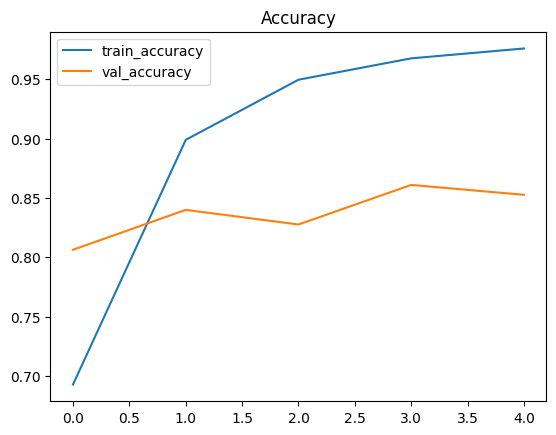

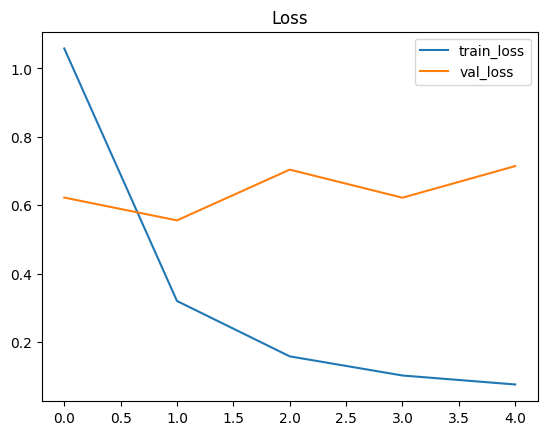

In [13]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

# Loss
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title('Loss')
plt.show()


In [15]:
import keras
keras.saving.save_model(model, 'my_model.keras')


In [17]:
model.save('my_model.keras')  # during saving
model = keras.models.load_model('my_model.keras')  # during loading


In [18]:
loss, accuracy = model.evaluate(val_generator)
print(f'Validation Loss: {loss:.4f}')
print(f'Validation Accuracy: {accuracy:.4f}')


439/439 ━━━━━━━━━━━━━━━━━━━━ 24s 52ms/step - accuracy: 0.8543 - loss: 0.7127
Validation Loss: 0.7145
Validation Accuracy: 0.8526


In [19]:
import numpy as np

# Example: predict on one batch of validation data
x_batch, y_batch = next(val_generator)
predictions = model.predict(x_batch)

# If it's a classification task, get the predicted class
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_batch, axis=1)

print("Predicted:", predicted_classes[:10])
print("Actual:   ", true_classes[:10])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step
Predicted: [28 35 31  8  9 13 37 16  7  5]
Actual:    [28 35 32  8  9 13 37 28  7  5]


In [21]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Preprocess data
x_test = x_test.astype("float32") / 255.0
x_test = x_test.reshape(-1, 28, 28, 1)  # Add channel dimension if using CNN
y_test = to_categorical(y_test, num_classes=10)  # One-hot encode labels


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
